In [ ]:
# step 1:import libriaries
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Titanic (2).csv to Titanic (2).csv


In [ ]:
#step 2:load dataset
df=pd.read_csv("Titanic (2).csv")
df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,0,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [ ]:
df.tail(9)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
905,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
906,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
907,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
908,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
909,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
910,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
911,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
912,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
913,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


In [ ]:
#step 3:data set formation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  914 non-null    int64  
 1   Pclass    914 non-null    int64  
 2   Name      913 non-null    object 
 3   Sex       913 non-null    object 
 4   Age       913 non-null    float64
 5   SibSp     914 non-null    int64  
 6   Parch     914 non-null    int64  
 7   Ticket    913 non-null    object 
 8   Fare      913 non-null    float64
 9   Embarked  913 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 71.5+ KB


In [ ]:
#step 4: data set cleaning
print("duplicate values count before cleaning",df.duplicated().sum())
#remove duplicates
df.drop_duplicates(inplace=True)
print("duplicate values count after cleaning",df.duplicated().sum())

duplicate values count before cleaning 23
duplicate values count after cleaning 0


In [ ]:
print("null values count before cleaning \n",df.isnull().sum())
df.dropna(inplace=True)
print("\n null values count after cleaning \n",df.isnull().sum())

null values count before cleaning 
 Survived    0
Pclass      0
Name        1
Sex         1
Age         1
SibSp       0
Parch       0
Ticket      1
Fare        1
Embarked    1
dtype: int64

 null values count after cleaning 
 Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


In [ ]:
#step 5:feature engineering
df.head()
df['Pclass']=df['Pclass'].astype('object')
df['Survived']=df['Survived'].astype('object')
df['Pclass']=df['Pclass'].replace({1:"First class",2:"Second class",3:"Third class"})
df['Embarked']=df['Embarked'].replace({"C":"Cherbourg","Q":"Queenstown","S":"Southampton"})
df['Survived']=df['Survived'].replace({0:"Dead",1:"Alive"})
df.rename(columns={'SibSp':'Number_of_siblings'},inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,Number_of_siblings,Parch,Ticket,Fare,Embarked
0,Dead,Third class,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton
1,Alive,First class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Cherbourg
2,Alive,Third class,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton
3,Alive,First class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton
4,Dead,Third class,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton


In [ ]:
# step 6:data summarization
df.groupby('Survived')['Age'].mean().reset_index()

,Survived,Age
0,Alive,28.424779
1,Dead,30.431444


In [ ]:
df.groupby('Survived')['Fare'].mean().reset_index()

,Survived,Fare
0,Alive,48.684170
1,Dead,21.703518


In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,Number_of_siblings,Parch,Ticket,Fare,Embarked
0,Dead,Third class,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton
1,Alive,First class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Cherbourg
2,Alive,Third class,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton
3,Alive,First class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton
4,Dead,Third class,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton


In [ ]:
df.groupby("Pclass")["Age"].mean().reset_index()
#Passengers in first class were older on average (38.8 years), while third-class passengers were the youngest (25.5 years).
#This shows a relationship between Pclass and Age, which can help in feature engineering and missing-value imputation in ML models.

,Pclass,Age
0,First class,38.776744
1,Second class,30.108696
2,Third class,25.472279


In [ ]:
df.groupby('Pclass')['Survived'].value_counts().reset_index()
#First-class passengers had the highest survival count compared to deaths, while third-class passengers had the highest number of deaths.

,Pclass,Survived,count
0,First class,Alive,136
1,First class,Dead,79
2,Second class,Dead,97
3,Second class,Alive,87
4,Third class,Dead,371
5,Third class,Alive,116


In [ ]:
df.groupby('Pclass')['Sex'].value_counts().reset_index()
#Third class had the highest number of male passengers, while first class had a relatively balanced male–female distbn.

,Pclass,Sex,count
0,First class,male,121
1,First class,female,94
2,Second class,male,108
3,Second class,female,76
4,Third class,male,346
5,Third class,female,141


In [ ]:
df.groupby('Pclass')['Parch'].value_counts().reset_index()
#Most passengers across all classes had Parch = 0, meaning they were traveling without parents or children.
#Third-class passengers had the largest family groups.

,Pclass,Parch,count
0,First class,0,163
1,First class,1,31
2,First class,2,20
3,First class,4,1
4,Second class,0,134
5,Second class,1,32
6,Second class,2,16
7,Second class,3,2
8,Third class,0,378
9,Third class,1,55


In [ ]:
a=df.groupby('Survived')['Number_of_siblings'].value_counts().reset_index();print(a)
#Passengers with no siblings(0) had the highest number of deaths, while passengers with one sibling showed comparatively better survival.

   Survived  Number_of_siblings  count
0     Alive                   0    208
1     Alive                   1    111
2     Alive                   2     13
3     Alive                   3      4
4     Alive                   4      3
5      Dead                   0    397
6      Dead                   1     97
7      Dead                   2     15
8      Dead                   4     15
9      Dead                   3     11
10     Dead                   8      7
11     Dead                   5      5


In [ ]:
df.groupby('Embarked')['Survived'].value_counts().reset_index()

,Embarked,Survived,count
0,Cherbourg,Alive,93
1,Cherbourg,Dead,75
2,Queenstown,Dead,47
3,Queenstown,Alive,28
4,Southampton,Dead,425
5,Southampton,Alive,218


In [ ]:
df.groupby('Embarked')['Sex'].value_counts().reset_index();print(a)

   Survived  Number_of_siblings  count
0     Alive                   0    208
1     Alive                   1    111
2     Alive                   2     13
3     Alive                   3      4
4     Alive                   4      3
5      Dead                   0    397
6      Dead                   1     97
7      Dead                   2     15
8      Dead                   4     15
9      Dead                   3     11
10     Dead                   8      7
11     Dead                   5      5


In [ ]:
avg = df.groupby("Sex")["Age"].mean()
print(avg)
count = df.query("Sex == 'male' and Survived == 'Alive' and Age > 31").shape[0]
count2 = df.query("Sex == 'female' and Survived == 'Alive' and Age > 27").shape[0]
print("Alive male with age>31 is ",count)
print("Alive female with age>27 is ",count2)

Sex
female    27.154341
male      31.020870
Name: Age, dtype: float64
Alive male with age>31 is  46
Alive female with age>27 is  111


In [ ]:
count1 = df.query("Sex == 'male' and Survived == 'Alive' and Age < 31").shape[0]
count2 = df.query("Sex == 'female' and Survived == 'Alive' and Age < 27").shape[0]
print("Alive male with age<31 is ",count1)
print("Alive female with age<27 is ",count2)

Alive male with age<31 is  60
Alive female with age<27 is  111


In [ ]:
count = df.query("Sex == 'male' and Survived == 'Alive' and Age > 31").shape[0]
c2 = df.query("Sex == 'male' and Survived == 'Alive' and Age <31").shape[0]
d0 = df.query("Sex == 'male' and Survived == 'Dead' and Age > 31").shape[0]
d11= df.query("Sex == 'male' and Survived == 'Dead' and Age < 31").shape[0]
print("ABOVE AVG. (Male) -- ",count1,"| Dead count --",d0)
print("BELOW AVG. (Male) -- ",count2,"| Dead count --",d11)
#--------------------------------------------------------------------------------
count1 = df.query("Sex == 'female' and Survived == 'Alive' and Age > 27").shape[0]
count2 = df.query("Sex == 'female' and Survived == 'Alive' and Age < 27").shape[0]
d1 = df.query("Sex == 'female' and Survived == 'Dead' and Age > 27").shape[0]
d2 = df.query("Sex == 'female' and Survived == 'Dead' and Age < 27").shape[0]
print("ABOVE AVG. (Female) -- ",count1,"| Dead count --",d1)
print("BELOW AVG. (Female) -- ",count2,"| Dead count --",d2)

ABOVE AVG. (Male) --  60 | Dead count -- 197
BELOW AVG. (Male) --  111 | Dead count -- 249
ABOVE AVG. (Female) --  111 | Dead count -- 26
BELOW AVG. (Female) --  111 | Dead count -- 53


In [ ]:
a1 = df.query("Pclass == 'First class' and Survived == 'Alive'").shape[0]
a2 = df.query("Pclass == 'First class' and Survived == 'Dead'").shape[0]

b1 = df.query("Pclass == 'Third class' and Survived == 'Alive'").shape[0]
b2 = df.query("Pclass == 'Third class' and Survived == 'Dead'").shape[0]

c1 = df.query("Pclass == 'Second class' and Survived == 'Alive'").shape[0]
c2 = df.query("Pclass == 'Second class' and Survived == 'Dead'").shape[0]
print("FIRST CLASS  -- Alive:", a1, "| Dead:", a2)
print("SECOND CLASS  -- Alive:", c1, "| Dead:", c2)
print("THIRD CLASS  -- Alive:", b1, "| Dead:", b2)

#1st class passengers had much better survival chances compared to 3rd class passengers.
#This suggests that safety of the 3rd class strongly affected.

FIRST CLASS  -- Alive: 136 | Dead: 79
SECOND CLASS  -- Alive: 87 | Dead: 97
THIRD CLASS  -- Alive: 116 | Dead: 371


In [ ]:

y1 = df.query("Age < 18 and Pclass == 'First class' and Survived == 'Alive'").shape[0]
y2 = df.query("Age < 18 and Pclass == 'First class' and Survived == 'Dead'").shape[0]

o1 = df.query("Age > 40 and Pclass == 'Third class' and Survived == 'Alive'").shape[0]
o2 = df.query("Age > 40 and Pclass == 'Third class' and Survived == 'Dead'").shape[0]

print("FIRST CLASS CHILDREN -- Alive:", y1, "| Dead:", y2)
print("THIRD CLASS AGE > 40 -- Alive:", o1, "| Dead:", o2)

#Children in first class had better survival chances, while older passengers in third class experienced higher death

FIRST CLASS CHILDREN -- Alive: 11 | Dead: 1
THIRD CLASS AGE > 40 -- Alive: 4 | Dead: 46


In [ ]:
s1 = df.query("Sex == 'female' and Embarked == 'Southampton' and Pclass == 'First class' and Survived == 'Alive'").shape[0]
s2 = df.query("Sex == 'female' and Embarked == 'Southampton' and Pclass == 'First class' and Survived == 'Dead'").shape[0]

c1 = df.query("Sex == 'male' and Embarked == 'Cherbourg' and Pclass == 'Third class' and Survived == 'Alive'").shape[0]
c2 = df.query("Sex == 'male' and Embarked == 'Cherbourg' and Pclass == 'Third class' and Survived == 'Dead'").shape[0]

print("FIRST CLASS FEMALES (S) -- Alive:", s1, "| Dead:", s2)
print("THIRD CLASS MALES (C) -- Alive:", c1, "| Dead:", c2)

FIRST CLASS FEMALES (S) -- Alive: 48 | Dead: 2
THIRD CLASS MALES (C) -- Alive: 10 | Dead: 33


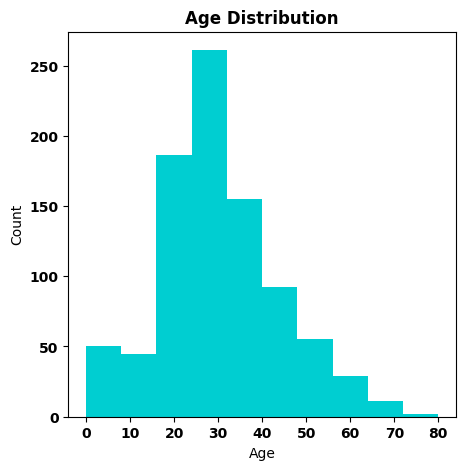

In [ ]:
#STEP 7: EDA
plt.figure(figsize=(5,5))
plt.hist(df["Age"],10,color="darkturquoise")
plt.title("Age Distribution",fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

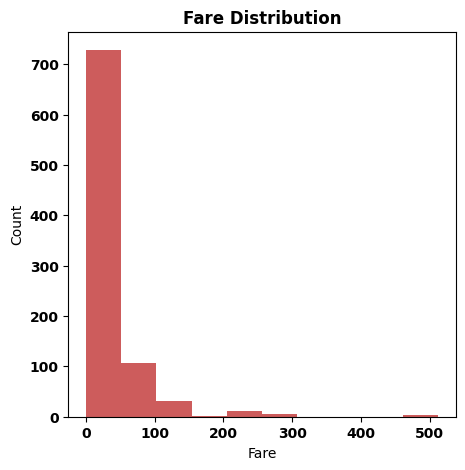

In [ ]:
plt.figure(figsize=(5,5))
plt.hist(df["Fare"],10,color="indianred")
plt.title("Fare Distribution",fontweight='bold')
plt.xlabel("Fare")
plt.ylabel("Count")
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

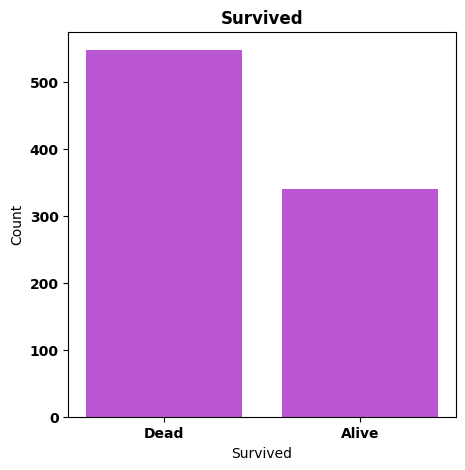

In [ ]:
a=df['Survived'].value_counts()
plt.figure(figsize=(5,5))
plt.bar(a.index,a.values,color="mediumorchid")
plt.title("Survived",fontweight='bold')
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

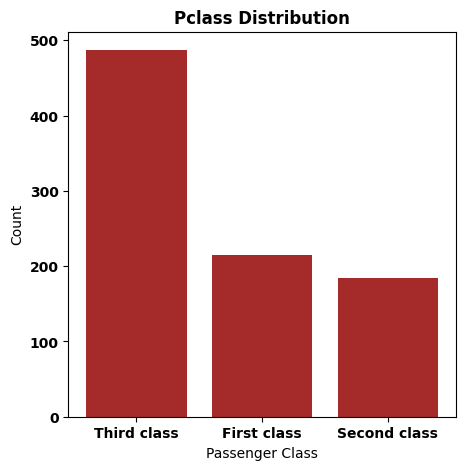

In [ ]:
a=df['Pclass'].value_counts()
plt.figure(figsize=(5,5))
plt.bar(a.index,a.values,color="brown")
plt.title("Pclass Distribution",fontweight='bold')
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

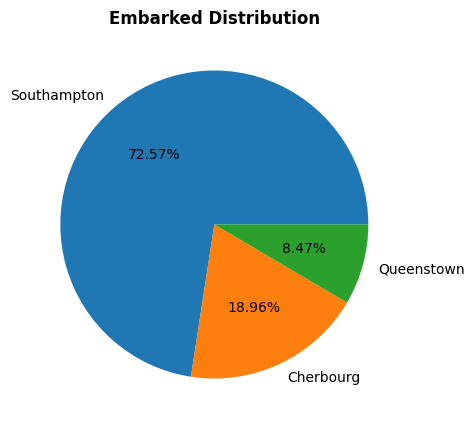

In [ ]:
a = df['Embarked'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(a.values, labels=a.index, autopct='%1.2f%%')
plt.title("Embarked Distribution", fontweight='bold')
plt.show()

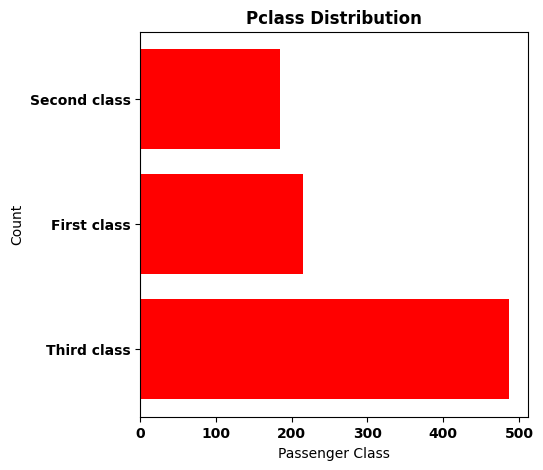

In [ ]:
a=df['Pclass'].value_counts()
plt.figure(figsize=(5,5))
plt.barh(a.index,a.values,color="red")
plt.title("Pclass Distribution",fontweight='bold')
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

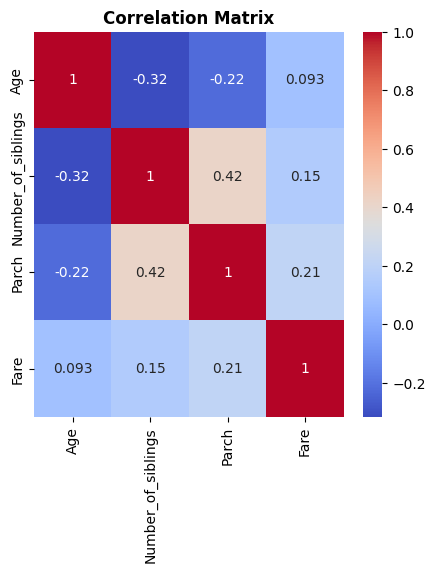

In [ ]:
plt.figure(figsize=(5,5))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix",fontweight='bold')
df.select_dtypes(exclude="object").columns
plt.show()

In [ ]:
#STEP 8:Converting category colm to binary
cat_cols=df.select_dtypes(include="object").columns
le=LabelEncoder()
for i in cat_cols:
  df[i]=le.fit_transform(df[i])
df.head()

,Survived,Pclass,Name,Sex,Age,Number_of_siblings,Parch,Ticket,Fare,Embarked
0,1,2,107,1,22.0,1,0,520,7.2500,2
1,0,0,189,0,38.0,1,0,593,71.2833,0
2,0,2,351,0,26.0,0,0,666,7.9250,2
3,0,0,270,0,35.0,1,0,49,53.1000,2
4,1,2,15,1,35.0,0,0,469,8.0500,2


In [ ]:
#Step 9: Split X and Y
X=df.drop(["Survived","Ticket","Name"],axis=1)
y=df["Survived"]

In [ ]:
X

,Pclass,Sex,Age,Number_of_siblings,Parch,Fare,Embarked
0,2,1,22.0,1,0,7.2500,2
1,0,0,38.0,1,0,71.2833,0
2,2,0,26.0,0,0,7.9250,2
3,0,0,35.0,1,0,53.1000,2
4,2,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,1,1,27.0,0,0,13.0000,2
887,0,0,19.0,0,0,30.0000,2
888,2,0,17.0,1,2,23.4500,2
889,0,1,26.0,0,0,30.0000,0


In [ ]:
y

,Survived
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,1
889,0


In [ ]:
#Step 10: train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#Step 11: Scaling / convert numerical columns
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#Step 12: Decision Tree Classification model
model=DecisionTreeClassifier()


In [ ]:
#STEP 13 : FIT MODEL
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
#STEP 14: MODEL PREDICTION
y_pred=model.predict(X_test)

In [ ]:
#STEP 15: MODEL ACCURACY
a=accuracy_score(y_test,y_pred)
print(f"Accuracy score: {a:.2f}")

Accuracy score: 0.74
